Understanding and Implementing K-Means and DBSCAN Algorithms

Objective:
The objective of this assignment is to introduce to various clustering algorithms, including K-Means, hierarchical, and DBSCAN, and provide hands-on experience in applying these techniques to a real-world dataset.
Datasets :
Data Preprocessing:
1.Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.Use multiple visualizations to understand the hidden patterns in the dataset
Implementing Clustering Algorithms:
Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

Cluster Analysis and Interpretation:
Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.
Evaluation and Performance Metrics:
Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

Data Preprocessing:
1.Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
2.Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
3.Use multiple visualizations to understand the hidden patterns in the dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [18]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [20]:
print("Shape :", df.shape)

Shape : (3999, 12)


In [21]:
print(df.columns)

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')


In [22]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [23]:
print(df.isnull().sum())

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


In [24]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [25]:
print(df.dtypes)

ID#                  int64
Balance              int64
Qual_miles           int64
cc1_miles            int64
cc2_miles            int64
cc3_miles            int64
Bonus_miles          int64
Bonus_trans          int64
Flight_miles_12mo    int64
Flight_trans_12      int64
Days_since_enroll    int64
Award?               int64
dtype: object


Observations:
1. Dataset loaded successfully.
2. No missing values found.
3. Duplicate values checked.
4. Statistical summary generated.
5. Dataset is ready for visualization.

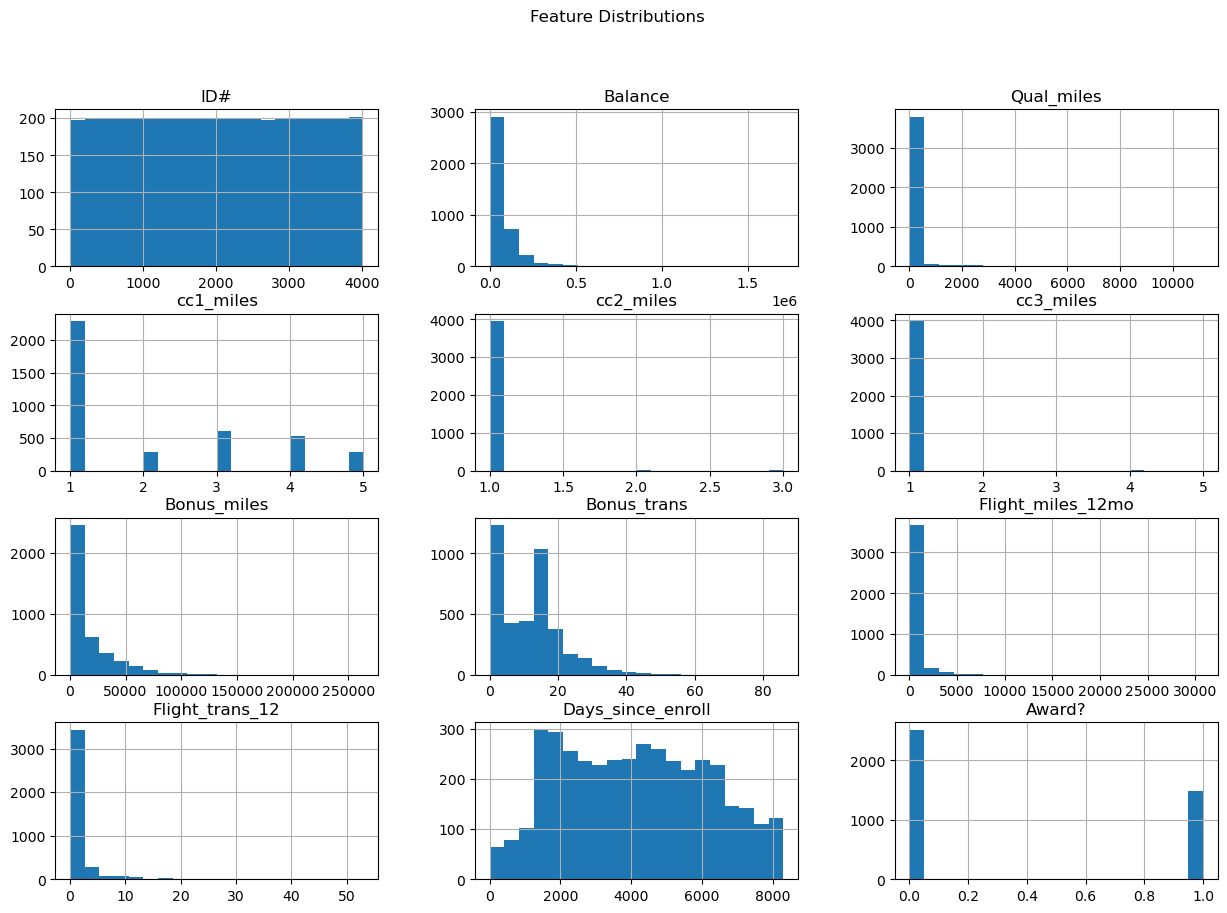

In [26]:
# Histogram (Only Numeric Columns)
df.select_dtypes(include=['number']).hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

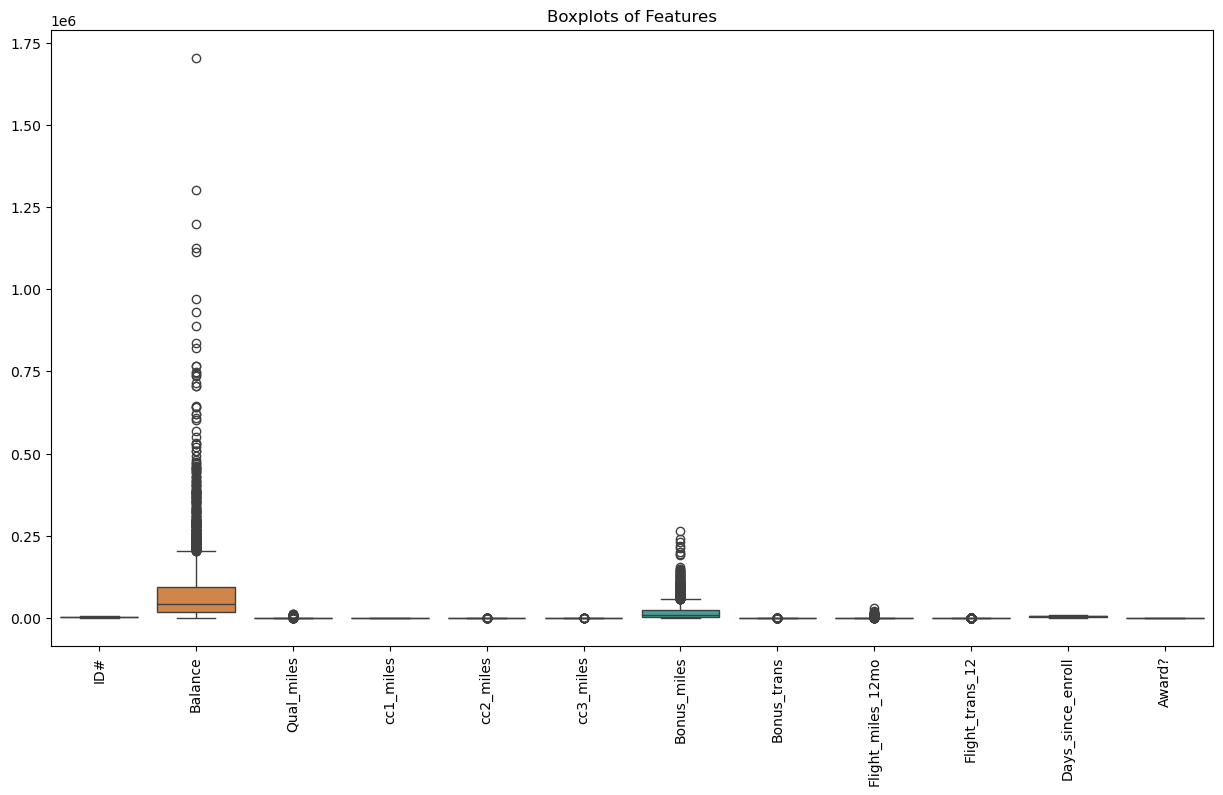

In [27]:
# Boxplots
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplots of Features")
plt.show()

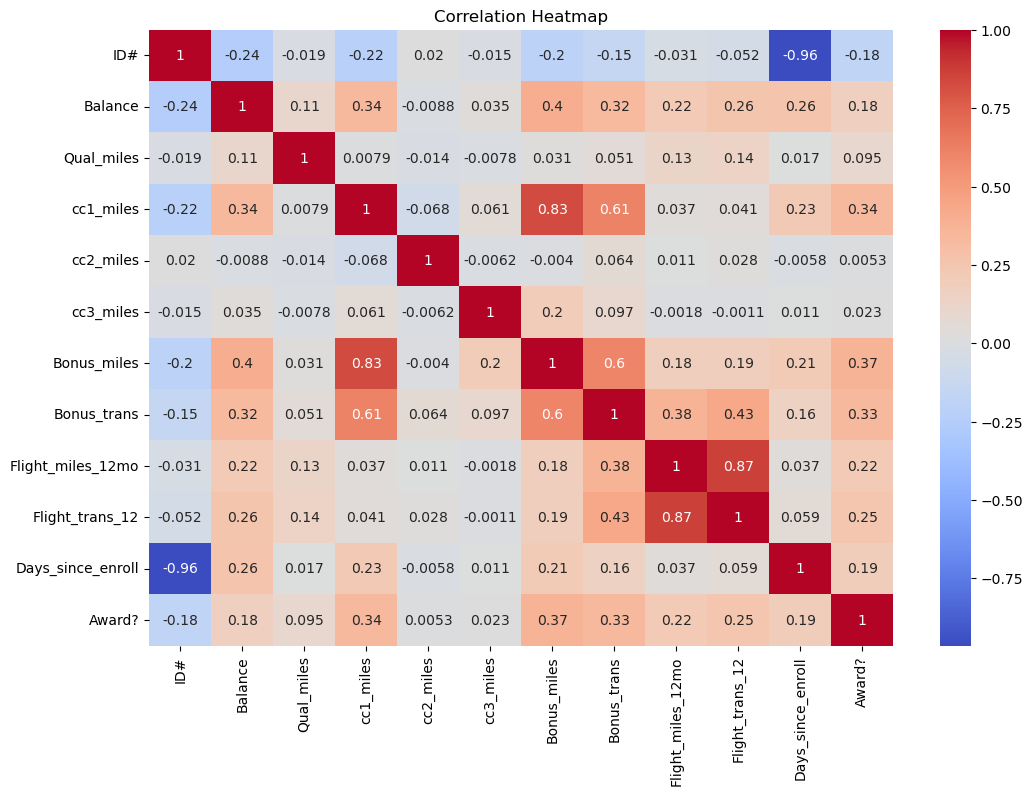

In [28]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

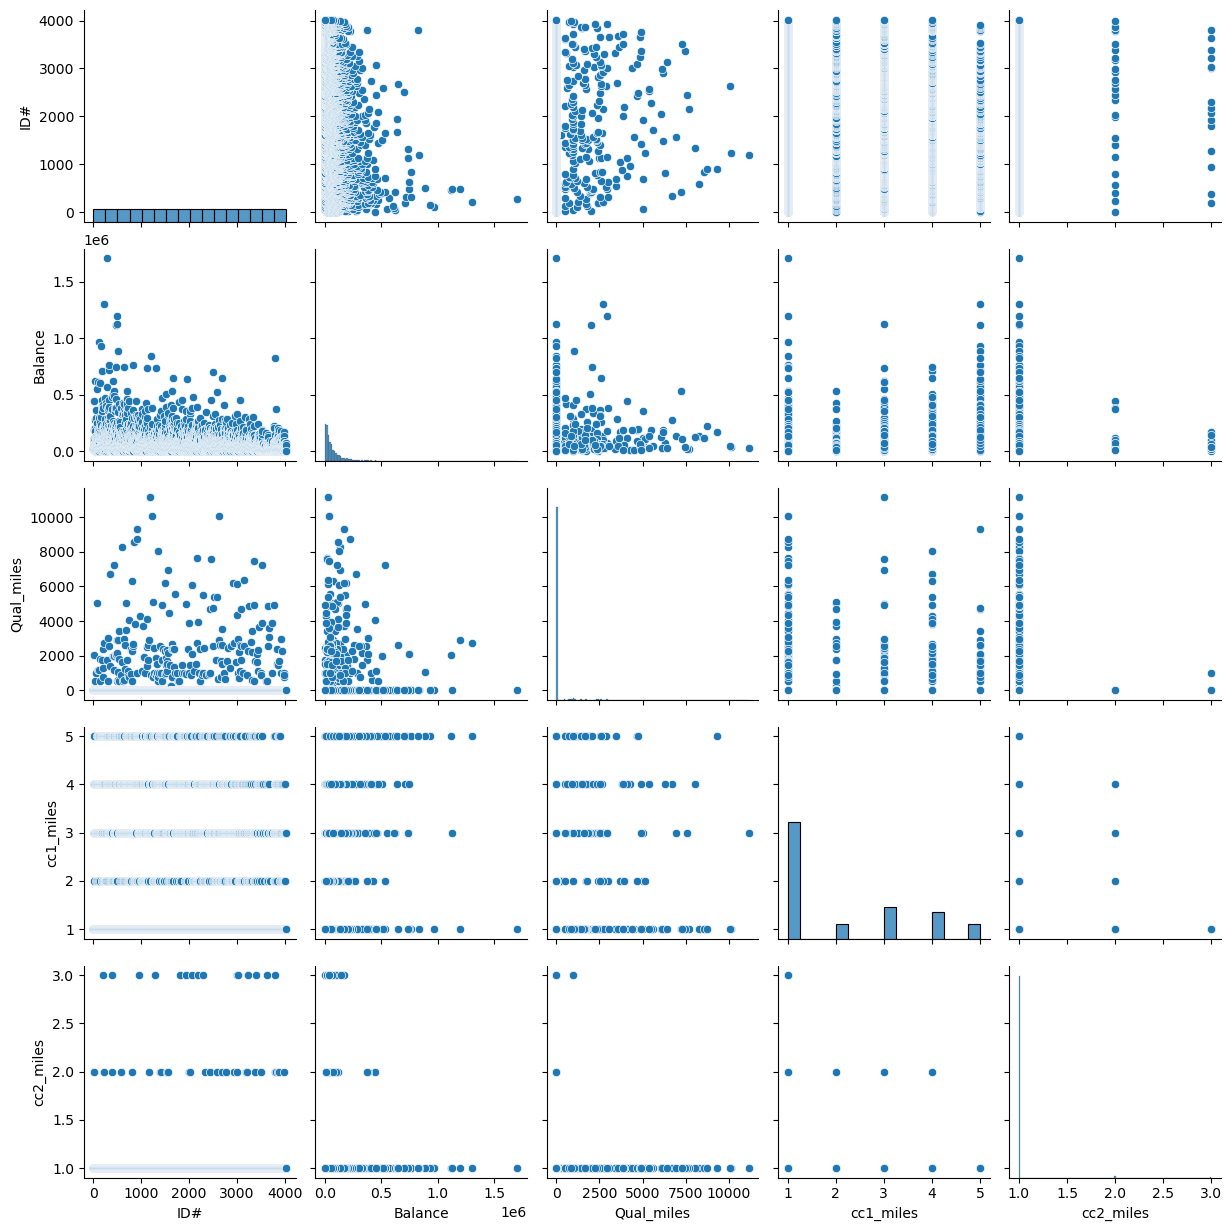

In [29]:
# Pair Plot 
sns.pairplot(df[df.columns[:5]])
plt.show()

1. Histograms show the distribution of each feature.
2. Boxplots help identify outliers in the dataset.
3. The heatmap shows positive and negative correlations between numerical features.
4. Pair plots help visualize relationships between selected features.

Implementing Clustering Algorithms:
Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df.drop("ID#", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

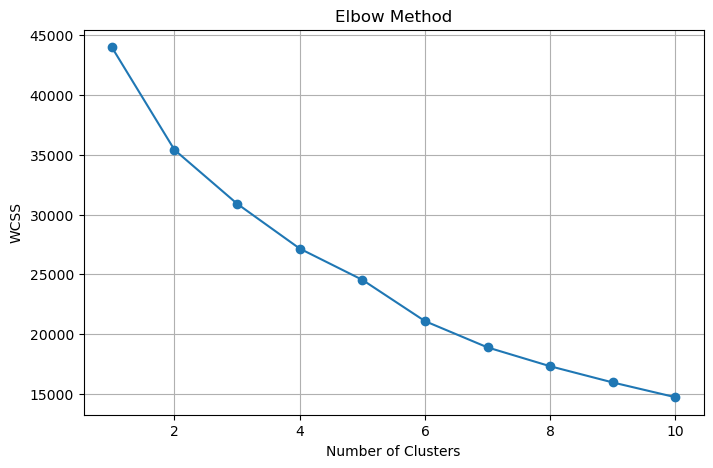

In [31]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

In [33]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,1
1,2,19244,0,1,1,1,215,2,0,0,6968,0,1
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,1
3,4,14776,0,1,1,1,500,1,0,0,6952,0,1
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,2


In [39]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

In [37]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,DBSCAN_Cluster
0,1,28143,0,1,1,1,174,1,0,0,7000,0,1,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,1,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,1,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,1,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,2,1


Cluster Analysis and Interpretation:
Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


In [40]:
print("K-Means Cluster Counts:")
print(df["KMeans_Cluster"].value_counts())

print("\nDBSCAN Cluster Counts:")
print(df["DBSCAN_Cluster"].value_counts())

K-Means Cluster Counts:
KMeans_Cluster
1    2543
2    1273
3     168
0      15
Name: count, dtype: int64

DBSCAN Cluster Counts:
DBSCAN_Cluster
 0    2411
 1    1250
-1     310
 2      15
 3       8
 4       5
Name: count, dtype: int64


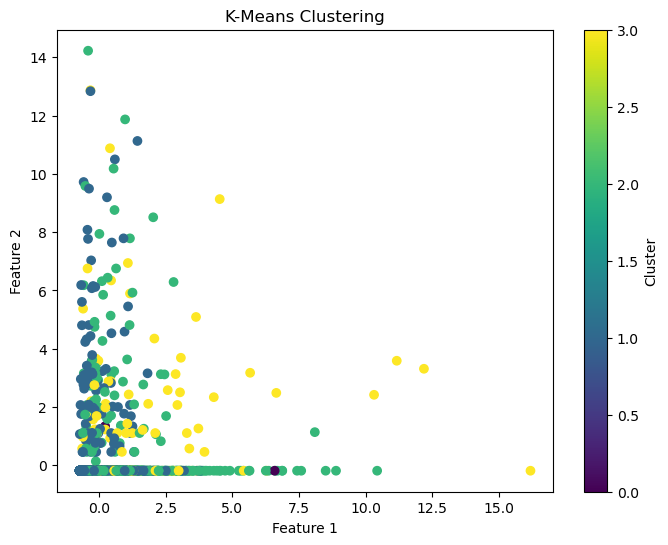

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df["KMeans_Cluster"],
    cmap="viridis"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()

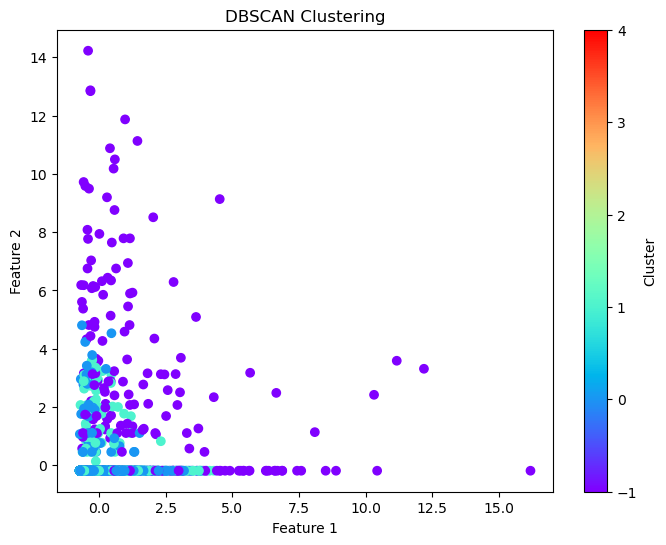

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df["DBSCAN_Cluster"],
    cmap="rainbow"
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()

1. K-Means divided the customers into multiple clusters.
2. DBSCAN identified dense groups and possible noise points.
3. K-Means works well for spherical clusters.
4. DBSCAN can detect outliers without specifying the number of clusters.
5. Both algorithms provide useful customer segmentation based on airline data.

Visualization:
Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.
Evaluation and Performance Metrics:

In [43]:
from sklearn.metrics import silhouette_score

# K-Means Score
kmeans_score = silhouette_score(X_scaled, df["KMeans_Cluster"])
print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.30918774313627845


In [44]:
# DBSCAN Score
dbscan_labels = df["DBSCAN_Cluster"]

In [45]:
# Ignore noise points (-1)
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN: Silhouette Score cannot be calculated.")

DBSCAN Silhouette Score: 0.29403795451062353


Evaluation:
1. Silhouette Score measures clustering quality.
2. Higher score indicates better cluster separation.
3. K-Means usually gives a stable silhouette score.
4. DBSCAN performance depends on eps and min_samples values.
5. Noise points are ignored while calculating DBSCAN Silhouette Score.

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

1. Use K-Means when the number of clusters is known and the data has well-separated groups.
2. Use DBSCAN when the dataset contains noise or clusters with irregular shapes.
3. Standardize data before applying clustering algorithms.
4. Evaluate clustering quality using metrics such as the Silhouette Score.
5. Choose the clustering algorithm based on the characteristics of the dataset and the business objective.